In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [ ]:
# Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [32]:
df_exploded = df.explode('job_skills')

In [33]:
df_exploded['job_skills'].value_counts().head(10)

job_skills
sql         384849
python      380909
aws         145381
azure       132527
r           130892
tableau     127213
excel       127018
spark       114609
power bi     98147
java         85612
Name: count, dtype: int64

In [39]:
skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()
type(skills_count) # Want to have this as a DataFrame

pandas.Series

In [40]:
df_skills_count = skills_count.reset_index(name='skills_count')

In [44]:
df_skills_count = df_skills_count.sort_values(by='skills_count', ascending=False)

In [45]:
job_title = 'Data Analyst'
top_skills = 10

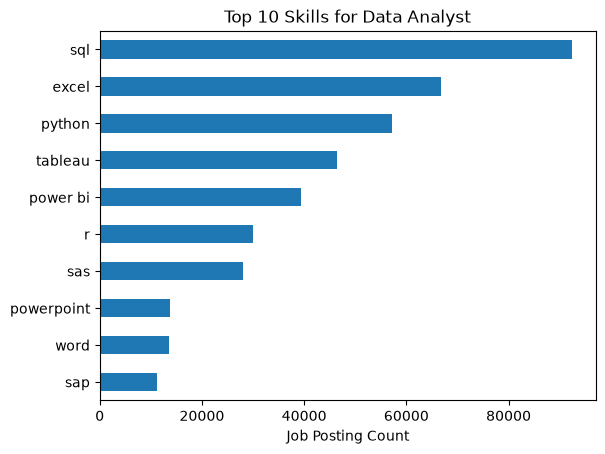

In [55]:
df_skills_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)
df_skills_final.plot(kind='barh', x='job_skills', y='skills_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()